In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import xgcm
import matplotlib.pyplot as plt
import xbudget

from load_example_ecco_grid import * 
from eccov4r4_budget_diagnostics import * 
print("xarray:",  xr.__version__)
print("xgcm:", xgcm.__version__)

xarray: 2026.4.0
xgcm: 0.9.0


In [3]:
ds = xr.open_dataset('../data/ecco_budget_terms_1yr.nc')

vars_i_to_ig = ['ADVx_TH', 'DFxE_TH', ]
vars_j_to_jg = ['ADVy_TH', 'DFyE_TH']
vars_k_to_k_l = ['ADVr_TH', 'DFrE_TH', 'DFrI_TH']

ds = ds.assign({
    'ETAN_bounds':  ds['ETAN'].rename({'time': 'time_bounds'}),
    'THETA_bounds': ds['THETA'].rename({'time': 'time_bounds'}),
    **{v: ds[v].swap_dims({'i': 'i_g'}) for v in vars_i_to_ig},
    **{v: ds[v].swap_dims({'j': 'j_g'}) for v in vars_j_to_jg},
    **{v: ds[v].swap_dims({'k': 'k_l'}) for v in vars_k_to_k_l},
}).drop_vars(['ETAN', 'THETA'])
ds

<xarray.Dataset> Size: 2GB
Dimensions:       (time: 12, k: 50, tile: 13, j: 90, i_g: 90, j_g: 90, i: 90,
                   k_l: 50, k_p1: 51, k_u: 50, time_bounds: 12)
Coordinates: (12/40)
  * time          (time) datetime64[ns] 96B 1992-01-01 1992-02-01 ... 1992-12-01
  * k             (k) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
    Z             (k) float32 200B ...
    PHrefC        (k) float32 200B ...
    drF           (k) float32 200B ...
  * tile          (tile) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
    ...            ...
    Zp1           (k_p1) float32 204B ...
    drC           (k_p1) float32 204B ...
    PHrefF        (k_p1) float32 204B ...
  * k_u           (k_u) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
    Zu            (k_u) float32 200B ...
  * time_bounds   (time_bounds) datetime64[ns] 96B 1992-01-01 ... 1992-12-01
Data variables:
    ADVx_TH       (time, k, tile, j, i_g) float32 253MB ...
    ADVy_TH       (time, k, tile, j_g, i) float32 253MB ...
    ADVr_TH       (time, k_l, tile, j, i) float32 253MB ...
    DFxE_TH       (time, k, tile, j, i_g) float32 253MB ...
    DFyE_TH       (time, k, tile, j_g, i) float32 253MB ...
    DFrE_TH       (time, k_l, tile, j, i) float32 253MB ...
    DFrI_TH       (time, k_l, tile, j, i) float32 253MB ...
    TFLUX         (time, tile, j, i) float32 5MB ...
    oceQsw        (time, tile, j, i) float32 5MB ...
    ETAN_bounds   (time_bounds, tile, j, i) float64 10MB ...
    THETA_bounds  (time_bounds, k, tile, j, i) float64 505MB ...

In [4]:
grid = construct_grid(ds)

In [5]:
# Build a time-step coordinate and a cell-volume metric used repeatedly below.
dt = grid._ds["time_bounds"].diff("time_bounds").rename({"time_bounds":"time"})
dt_values = dt.dt.total_seconds().values
dt_values = np.concatenate([dt_values,[dt_values[-1]]])

grid._ds = grid._ds.assign_coords(
    {"dt":("time", dt_values), 
    "volcello": (grid._ds["drF"] * grid._ds["hFacC"]) * grid._ds["rA"]
    })

#need to do this to get the correct differences for snapshots
grid._ds = grid._ds.isel(time = slice(1, -1), time_bounds = slice(1, None)) 
grid._ds

<xarray.Dataset> Size: 2GB
Dimensions:       (time: 10, k: 50, tile: 13, j: 90, i_g: 90, j_g: 90, i: 90,
                   k_l: 50, k_p1: 51, k_u: 50, time_bounds: 11)
Coordinates: (12/42)
  * time          (time) datetime64[ns] 80B 1992-02-01 1992-03-01 ... 1992-11-01
    dt            (time) float64 80B 2.506e+06 2.678e+06 ... 2.678e+06 2.592e+06
  * k             (k) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
    Z             (k) float32 200B -5.0 -15.0 -25.0 ... -5.461e+03 -5.906e+03
    PHrefC        (k) float32 200B 49.05 147.1 245.2 ... 5.357e+04 5.794e+04
    drF           (k) float32 200B 10.0 10.0 10.0 10.0 ... 410.5 433.5 456.5
    ...            ...
    Zp1           (k_p1) float32 204B ...
    drC           (k_p1) float32 204B ...
    PHrefF        (k_p1) float32 204B ...
  * k_u           (k_u) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
    Zu            (k_u) float32 200B ...
  * time_bounds   (time_bounds) datetime64[ns] 88B 1992-02-01 ... 1992-12-01
Data variables:
    ADVx_TH       (time, k, tile, j, i_g) float32 211MB ...
    ADVy_TH       (time, k, tile, j_g, i) float32 211MB ...
    ADVr_TH       (time, k_l, tile, j, i) float32 211MB ...
    DFxE_TH       (time, k, tile, j, i_g) float32 211MB ...
    DFyE_TH       (time, k, tile, j_g, i) float32 211MB ...
    DFrE_TH       (time, k_l, tile, j, i) float32 211MB ...
    DFrI_TH       (time, k_l, tile, j, i) float32 211MB ...
    TFLUX         (time, tile, j, i) float32 4MB ...
    oceQsw        (time, tile, j, i) float32 4MB ...
    ETAN_bounds   (time_bounds, tile, j, i) float64 9MB ...
    THETA_bounds  (time_bounds, k, tile, j, i) float64 463MB ...

In [6]:
def zero_top_layer(ds, varname = "", zdim = "k_l"):
    # Remove the surface layer contribution when a diagnostic should only represent interior transport.
    return xr.where(ds[f"{zdim}"] != ds[f"{zdim}"].isel({f"{zdim}":0}),ds[varname].copy(),0.0,)
def make_flux_3d(ds, varname = "", zdim = "k"):
    # Broadcast a surface flux into a 3D array that only occupies the top model layer.
    k  = ds[f"{zdim}"]
    return xr.where(k == k.isel({f"{zdim}":0}), ds[varname].copy().expand_dims({f"{zdim}":k}),0.0,)

# Assemble ECCO heat-flux terms into the budget components expected by xbudget.
#grid._ds["geothermal_heat_flux_convergence"] = eccov4r4_geothermal_heat_flux_tendency(grid._ds) 
grid._ds["pen_boundary_forcing_heat_tendency"] = eccov4r4_penetrative_heat_flux_tendency(grid._ds)
grid._ds["nonpen_boundary_forcing_heat_tendency"] = eccov4r4_nonpenetrative_heat_flux_tendency(grid._ds)
grid._ds["boundary_forcing_heat_tendency"] = grid._ds["pen_boundary_forcing_heat_tendency"] + grid._ds["nonpen_boundary_forcing_heat_tendency"]

In [7]:
# Put the sea-ice salt exchange and salt-plume tendency onto the same vertical grid.
#SFLUX = grid._ds["SFLUX"].assign_coords(k=0).expand_dims(dim='k',axis=1) # sea-ice salt exchange
#grid._ds["boundary_forcing_salt_tendency"] = xr.concat([SFLUX+grid._ds["oceSPtnd"],grid._ds["oceSPtnd"].isel(k=slice(1,None))], dim='k') # combine surface salt flux and plume tendency

# Separate interior vertical transport from the freshwater boundary forcing term.
#grid._ds["WVELMASS_interior"] = zero_top_layer(grid._ds, varname = "WVELMASS", zdim = "k_l") #
#grid._ds["boundary_forcing_volume_tendency"] = make_flux_3d(grid._ds, varname = "oceFWflx", zdim = "k")

# Rechunk once before calling xbudget so later difference and convergence steps stay tractable.
grid._ds = grid._ds.chunk({"tile":2, "i":50, "j":50, "i_g":50, "j_g":50, "k": 10}).fillna(0.0)
# to-do: add comparable chunking inside the difference and convergence routines 

In [8]:
# Load the preset metadata dictionary and let xbudget attach the derived budget terms.
xbudget_dict = xbudget.load_preset_budget(model="ECCOV4r4_native").copy()
xbudget.collect_budgets(grid, xbudget_dict,allow_rechunk= True)
# Aggregate the full metadata tree into a simpler budget summary for inspection.
simple_budgets = xbudget.aggregate(xbudget_dict)
simple_budgets

/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/collect.py:239: UserWarning: Variable UVELMASS is missing from the dataset `ds`, so it is being skipped. To suppress this warning, remove UVELMASS from the `xbudget_dict`.
  warnings.warn(f"Variable {v_term} is missing from the dataset `ds`, so it is being skipped. To suppress this warning, remove {v_term} from the `xbudget_dict`.", UserWarning)
/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/collect.py:239: UserWarning: Variable VVELMASS is missing from the dataset `ds`, so it is being skipped. To suppress this warning, remove VVELMASS from the `xbudget_dict`.
  warnings.warn(f"Variable {v_term} is missing from the dataset `ds`, so it is being skipped. To suppress this warning, remove {v_term} from the `xbudget_dict`.", UserWarning)
/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstitut

{'mass': {'lambda': 'density',
  'thickness': 'thkcello',
  'lhs': {'Eulerian_tendency': 'mass_lhs_sum_Eulerian_tendency'},
  'rhs': {'advection': 'mass_rhs_sum_advection',
   'surface_exchange_flux': 'mass_rhs_sum_surface_exchange_flux'}},
 'heat': {'lambda': 'THETA',
  'lhs': {'Eulerian_tendency': 'heat_lhs_sum_Eulerian_tendency'},
  'rhs': {'advection': 'heat_rhs_sum_advection',
   'diffusion': 'heat_rhs_sum_diffusion',
   'surface_exchange_flux': 'heat_rhs_sum_surface_exchange_flux'}},
 'salt': {'lambda': 'SALT',
  'lhs': {'Eulerian_tendency': 'salt_lhs_sum_Eulerian_tendency'},
  'rhs': {'surface_exchange_flux': 'salt_rhs_sum_surface_exchange_flux'}}}

In [9]:
def plot_interpolated_ecco(fig, ax, ds, vmin=0, vmax=30, cmap="coolwarm"):
    # Build a simple regular lat-lon target grid for quick visual comparison.
    target_lon = np.arange(-180, 180, 1)
    target_lat = np.arange(-90, 90, 1)
    lon_grid, lat_grid = np.meshgrid(target_lon, target_lat)
    
    # Flatten the LLC field into point/value pairs for interpolation.
    points = np.column_stack((ds.XC.values.ravel(), ds.YC.values.ravel()))
    values = ds.values.ravel()
    
    # Use nearest-neighbor remapping to preserve the native diagnostic values.
    interpolated_data = griddata(points, values, (lon_grid, lat_grid), method='nearest')
    
    # Plot the remapped field.
    cb = ax.pcolormesh(lon_grid, lat_grid, interpolated_data, 
                       vmin=vmin, vmax=vmax, cmap=cmap)
    
    return cb

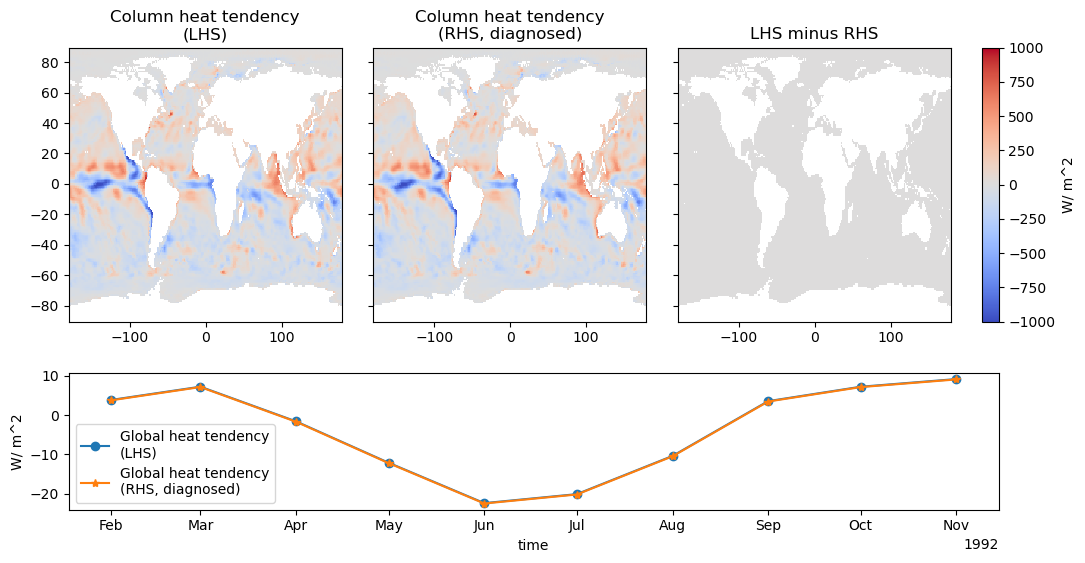

In [40]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1,  0.06], height_ratios=[1, 0.5], hspace=0.25, wspace=0.15)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0); ax1.tick_params(labelleft=False)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0); ax2.tick_params(labelleft=False)
cax = fig.add_subplot(gs[0, 3])
ax_bottom = fig.add_subplot(gs[1, :])

# Restrict horizontal area to wet points before forming column integrals.
area = grid._ds["rA"].where(grid._ds["Depth"] > 0.0)

# Convert native volume-integrated heat tendencies into column tendencies per unit area.
lhs_tendency = (grid._ds[xbudget.get_vars(xbudget_dict, "heat_lhs")['var']] / area).sum("k") # convert from J/s to W/m^2
lhs_tendency = lhs_tendency.where(np.abs(lhs_tendency) > 0.0)

rhs_tendency = (grid._ds[xbudget.get_vars(xbudget_dict, "heat_rhs")['var']] / area).sum("k")
rhs_tendency = rhs_tendency.where(np.abs(rhs_tendency) > 0.0)

# Residual should be small if the budget closes.
tendency_difference = lhs_tendency - rhs_tendency

vmax = 1000
plot_interpolated_ecco(fig, ax0, lhs_tendency.isel(time=2), vmin=-vmax, vmax=vmax); ax0.set_title("Column heat tendency\n(LHS)")
plot_interpolated_ecco(fig, ax1, rhs_tendency.isel(time=2), vmin=-vmax, vmax=vmax); ax1.set_title("Column heat tendency\n(RHS, diagnosed)")
cb = plot_interpolated_ecco(fig, ax2, tendency_difference.isel(time=2), vmin=-vmax, vmax=vmax); ax2.set_title("LHS minus RHS")
fig.colorbar(cb, cax=cax, orientation="vertical", label = "W/ m^2")

# Area-weighted global means summarize the closure error over time.
((lhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "o", label = "Global heat tendency\n(LHS)")
((rhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "*", label = "Global heat tendency\n(RHS, diagnosed)")
ax_bottom.set_ylabel("W/ m^2")
ax_bottom.legend()

### Note to Noah: The "lhs" and "rhs" of the budgets are calculated in Joules per second (sorry). The benefit of this is that to get an average temperature tendency, you just need to add up all the points in a region and then divide by its volume. Below is an example of that normalization. 

In [82]:
lats3d = grid._ds["YC"].broadcast_like(grid._ds["hFacC"])
depths3d = grid._ds["Z"].broadcast_like(grid._ds["hFacC"])

upper_southern_ocean_mask = 1.0 * (lats3d < -62.0) * (depths3d > -700.0)
upper_southern_ocean_mask = upper_southern_ocean_mask.where(grid._ds["hFacC"] > 0.0).fillna(0.0)

spatial_mask = xr.where(upper_southern_ocean_mask.sum('k') > 0, 1, np.nan)

### to get the tendency of a region in deg C / s, sum the J/s tendencies and normalize by (1) the region's volume (2) a reference density (3) the specific heat of seawater

In [ ]:
rho = 1029.0
cp = 3994.0

lhs_tendency = grid._ds[xbudget.get_vars(xbudget_dict, "heat_lhs")['var']]

#mask and apply sum
rhs_tendency_ds = grid._ds[xbudget.get_vars(xbudget_dict, "heat_rhs")['var']]
rhs_tendency_ds = rhs_tendency_ds.rename("rhs").to_dataset()
rhs_tendency_ds["rhs_advection"] = grid._ds[xbudget.get_vars(xbudget_dict, "heat_rhs_advection")]
rhs_tendency_ds["rhs_diffusion"] = grid._ds[xbudget.get_vars(xbudget_dict, "heat_rhs_diffusion")]
rhs_tendency_ds["rhs_surface_flux"] = grid._ds[xbudget.get_vars(xbudget_dict, "heat_rhs_surface_exchange_flux")]

fig, ax = plt.subplots(1, 2, figsize = (14, 4))

cb = plot_interpolated_ecco(fig, ax[0], spatial_mask, vmin=0, vmax=1); ax0.set_title("Column heat tendency\n(LHS)")
ax[0].set_title("Region mask")                                                               
ax[0].set_xlabel("Lon")                                                               
ax[0].set_ylabel("Lat")                                                               

#get the volume in the mask
mask_volume = grid._ds["volcello"].where(upper_southern_ocean_mask > 0.0).sum(["tile", "k", "i", "j"])

#mask and apply sum
rhs_tendency = rhs_tendency_ds.where(upper_southern_ocean_mask > 0.0)
rhs_tendency = rhs_tendency.sum(["tile", "k", "i", "j"]) / (mask_volume * rho * cp)

lhs_tendency = lhs_tendency.where(upper_southern_ocean_mask > 0.0)
lhs_tendency = lhs_tendency.sum(["tile", "k", "i", "j"]) / (mask_volume * rho * cp)

lhs_tendency.plot(ax = ax[1], label = "regional heat tendency (lhs)", c = "k")
rhs_tendency["rhs"].plot(ax = ax[1],label = "regional heat tendency (rhs, diagnosed)", linestyle = "--", c = "red")         
rhs_tendency["rhs_advection"].plot(ax = ax[1],label = "heat advection")         
rhs_tendency["rhs_diffusion"].plot(ax = ax[1],label = "heat diffusion")         
rhs_tendency["rhs_surface_flux"].plot(ax = ax[1],label = "surface heat fluxes")         
ax[1].legend()
ax[1].set_ylabel("deg C per second")   
ax[1].set_title("Regional heat budget")                                                               
